# Credit Risk Prediction

## Introduction
Credit risk prediction is an important problem in the banking and financial sector. The objective of this project is to predict whether a loan applicant is likely to default on a loan based on their personal and financial information.

## Problem Statement
The goal is to build a machine learning classification model that can predict loan status (approved/rejected or default/non-default) using applicant details such as income, education, loan amount, and other relevant features.



In [2]:
#Importing Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Dataset Understanding

The Loan Prediction Dataset contains information about loan applicants, including demographic and financial attributes. The target variable is Loan_Status, which indicates whether the loan application was approved or not.

In [4]:
df = pd.read_csv("test.csv")

In [5]:
df = pd.read_csv("train.csv")

In [6]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### Dataset Exploration

In [7]:
df.shape

(614, 13)

In [8]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [11]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## Data Cleaning and Preparation

Before training the model, missing values need to be handled appropriately to improve model performance.

In [10]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


### Fill the missing values

In [16]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [17]:
#Again checking
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


## Exploratory Data Analysis (EDA)

The following visualizations help us understand the distribution of important variables and their relationship with loan approval.

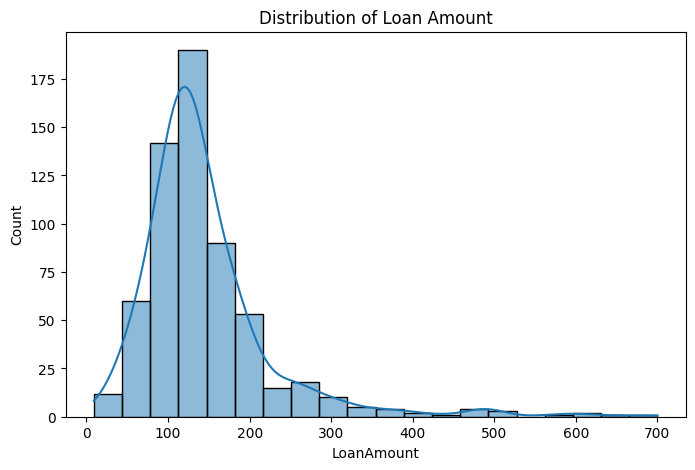

In [22]:
#Loan Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['LoanAmount'], bins=20, kde=True)
plt.title("Distribution of Loan Amount")
plt.show()

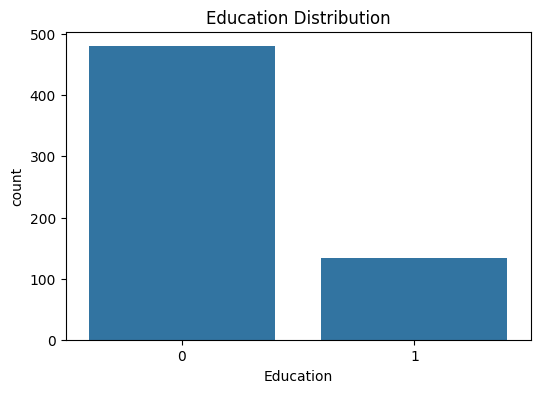

In [23]:
#Education Count
plt.figure(figsize=(6,4))
sns.countplot(x='Education', data=df)
plt.title("Education Distribution")
plt.show()

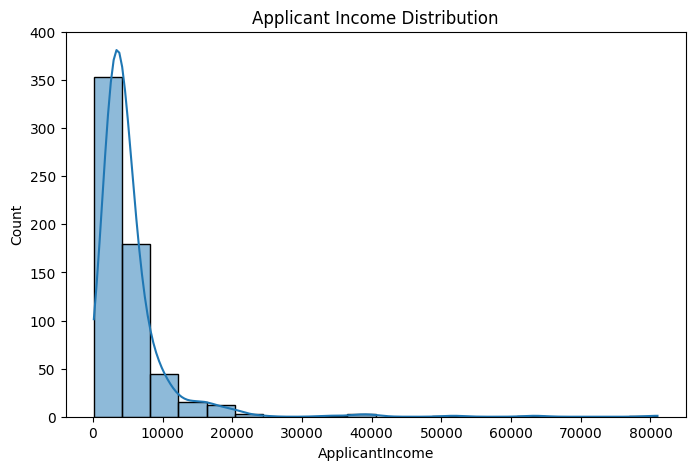

In [24]:
#Applicant Income Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['ApplicantIncome'], bins=20, kde=True)
plt.title("Applicant Income Distribution")
plt.show()

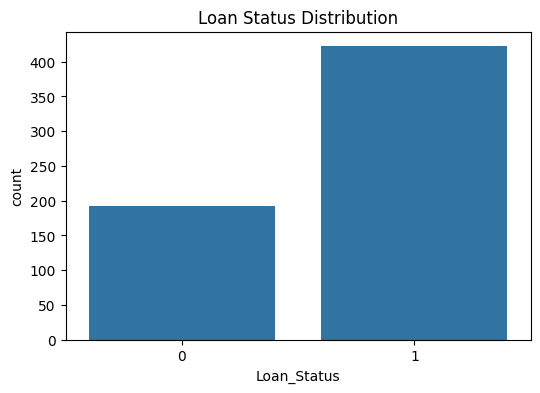

In [25]:
#Loan Status Count
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Distribution")
plt.show()

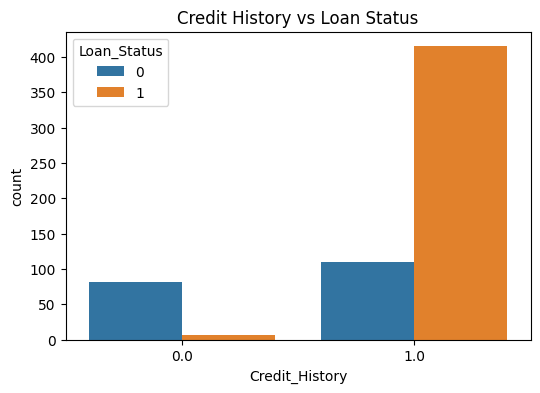

In [26]:
#Credit Historu vs Loan Status
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Status")
plt.show()

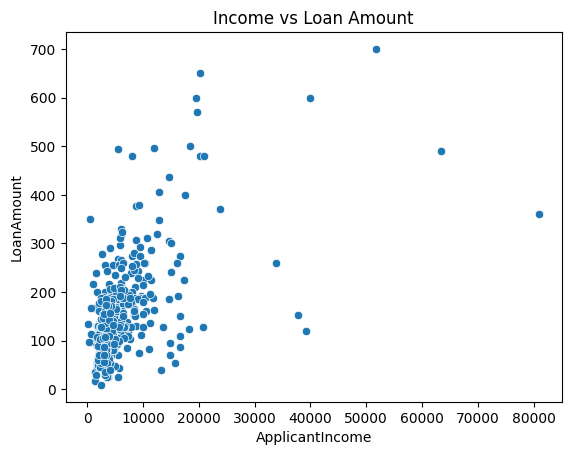

In [ ]:
#Income vs Loan Amount
sns.scatterplot(
    x="ApplicantIncome",
    y="LoanAmount",
    data=df
)

plt.title("Income vs Loan Amount")

plt.show()

### Encoding Categorail Data

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [19]:
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [20]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


### Feature Selection

In [27]:
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

### Train Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training and Testing

Two classification models are trained and evaluated:

1. Logistic Regression
2. Decision Tree Classifier

In [ ]:
#Logistic Registeration
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

### Desicision Tree

In [31]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

### Model Evaluation

#### 1:Logistic Registration

In [32]:
#Accuracy
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy:
0.7886178861788617


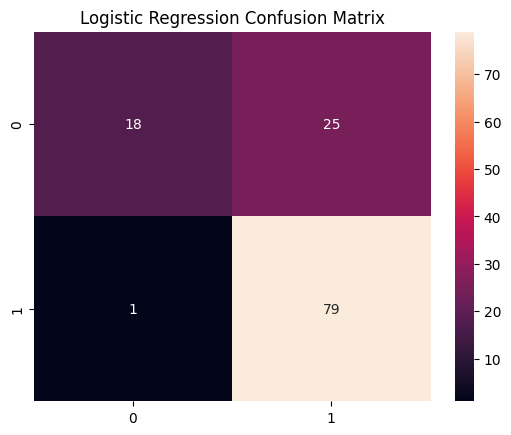

In [33]:
#Confusion matrix
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [34]:
#Classification Report
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



###Descision Tree

In [35]:
#Accuracy
print("Decision Tree Accuracy:")
print(accuracy_score(y_test, dt_pred))

Decision Tree Accuracy:
0.6910569105691057


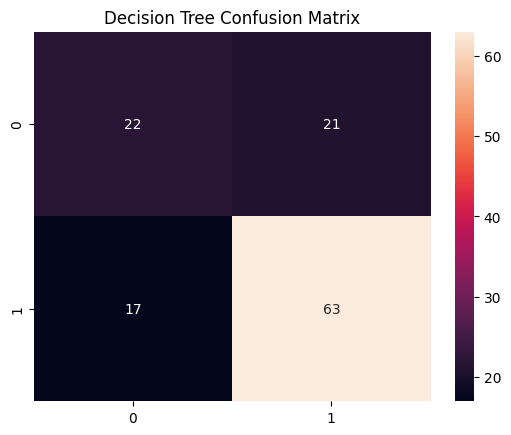

In [36]:
#Confusion Matrix
cm = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

## Conclusion

In this project, a Credit Risk Prediction model was developed using the Loan Prediction Dataset.

### Key Steps Performed:
- Data cleaning and handling missing values
- Exploratory Data Analysis (EDA)
- Feature encoding
- Model training using Logistic Regression and Decision Tree
- Model evaluation using Accuracy Score and Confusion Matrix

### Key Insights:
- Credit history plays an important role in loan approval.
- Applicant income and loan amount also influence loan decisions.
- Logistic Regression and Decision Tree successfully classified loan applications.

The model can help financial institutions make better lending decisions by predicting loan risk.